In [114]:
import destruction_models as models
from tensorflow.keras import callbacks, metrics
from tensorflow.keras.utils import Sequence
from destruction_utilities import *
import matplotlib.pyplot as plt
import tensorflow as tf
import time
import pickle
from tensorflow.keras.models import load_model
from sklearn.metrics import precision_recall_curve, roc_auc_score, precision_score, recall_score

from tensorflow.keras.metrics import CategoricalAccuracy, Precision, AUC


In [115]:
CITY = 'test'
BATCH_SIZE = 32
TILE_SIZE = [128,128]

auc = AUC(
    num_thresholds=200,
    curve='ROC',
    name="auc"
)

In [116]:
class SiameseGenerator(Sequence):
    def __init__(self, images, labels, batch_size=BATCH_SIZE):
        self.images_t0 = images[0]
        self.images_tt = images[1]
        self.labels = labels
        self.batch_size = batch_size
        self.tuple_pairs = make_tuple_pair(self.images_t0.shape[0], self.batch_size)
        np.random.shuffle(self.tuple_pairs)
   
   
    def __len__(self):
        return len(self.images_t0)//self.batch_size
    
    def __getitem__(self, index):
        
        index_range = self.tuple_pairs[index]
        indices = np.arange(0,32)
        np.random.shuffle(indices)

        X_t0 = self.images_t0[index_range[0]:index_range[1]][indices]
        X_t1 = self.images_tt[index_range[0]:index_range[1]][indices]
        y = self.labels[index_range[0]:index_range[1]][indices]
        
        alpha = random.choice(np.linspace(0.85, 1.4))
        
        return {'images_t0':X_t0 *alpha, 'images_tt':X_t1 *alpha}, y

    def augment(self, X):
#         # Horizontal and vertical flip
#         flipping_funcs = [
#             lambda image: image,
#             lambda image: np.fliplr(image),
#             lambda image: np.flipud(image),
#             lambda image: np.flipud(np.fliplr(image))
#         ]
#         func = random.choice(flipping_funcs)
#         X = func(X)
        
        # Brightness
        alpha = random.choice(np.linspace(0.85, 1.4))
#         alpha = 1
        X = X * alpha

        return X

In [117]:
def run_model_dist(train_images, train_labels, valid_images, valid_labels, run_id = 1):
    train_gen = SiameseGenerator((train_images[0], train_images[1]), train_labels)
    valid_gen = SiameseGenerator((valid_images[0], valid_images[1]), valid_labels)
    
    training_callbacks = [
        callbacks.EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True),
        callbacks.ModelCheckpoint(f'../models/{CITY}/snn/run_{i}/', monitor='val_auc', verbose=0, save_best_only=True, save_weights_only=False, mode='max')
    ]
    
    filters = random.choice([16,32])
    dropout = random.choice(np.linspace(0.1, 0.2))
    epochs = random.choice(np.arange(70,100))
    units = random.choice([32])
    lr = random.choice([0.003, 0.01, 0.03])

    args  = dict(filters=filters, dropout=dropout, units=units) # ! Check parameters before run

    parameters = f'filters={filters}, \ndropout={np.round(dropout, 4)}, \nepochs={epochs}, \nunits={units}, \nlearning_rate={lr}'
    print(parameters)
    
#     model = models.siamese_convolutional_network(shape=(*TILE_SIZE, 3), args_encode=args_encode, args_dense=args_dense)
    model = models.siamese_convolutional_network_dist(
        shape=(*TILE_SIZE, 3),  
        args = args,
    )
   
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy',metrics.AUC(num_thresholds=200, curve='ROC', name='auc')])
    model.summary()
    

    # Train model on dataset
    history = model.fit_generator(
        train_gen,
        validation_data=valid_gen,
        epochs=epochs,
        verbose=1,
        callbacks=training_callbacks
    )
    
    return model, history, parameters


In [118]:
def run_model(train_images, train_labels, valid_images, valid_labels, run_id = 1):
    train_gen = SiameseGenerator((train_images[0], train_images[1]), train_labels)
    valid_gen = SiameseGenerator((valid_images[0], valid_images[1]), valid_labels)
    
    training_callbacks = [
        callbacks.EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True),
        callbacks.ModelCheckpoint(f'../models/{CITY}/snn/run_{i}/', monitor='val_auc', verbose=0, save_best_only=True, save_weights_only=False, mode='max')
    ]
    
    filters = random.choice([16,32])
    dropout = random.choice(np.linspace(0.1, 0.2))
    epochs = random.choice(np.arange(70,100))
    units = random.choice([32])
    lr = random.choice([0.003, 0.01, 0.03])

    args_encode  = dict(filters=filters, dropout=dropout) # ! Check parameters before run
    args_dense  = dict(units=units) # ! Check parameters before run

    parameters = f'filters={filters}, \ndropout={np.round(dropout, 4)}, \nepochs={epochs}, \nunits={units}, \nlearning_rate={lr}'
    print(parameters)
    
#     model = models.siamese_convolutional_network(shape=(*TILE_SIZE, 3), args_encode=args_encode, args_dense=args_dense)
    model = models.siamese_convolutional_network(shape=(*TILE_SIZE, 3),  args_encode=dict(filters=filters, dropout=dropout), args_dense=dict(units=units, dropout=dropout))
   
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy',metrics.AUC(num_thresholds=200, curve='ROC', name='auc')])
    model.summary()
    

    # Train model on dataset
    history = model.fit_generator(
        train_gen,
        validation_data=valid_gen,
        epochs=epochs,
        verbose=1,
        callbacks=training_callbacks
    )
    
    return model, history, parameters

In [119]:
train_images_t0 = read_zarr(CITY, 'images_siamese_train_t0_balanced')
train_images_tt = read_zarr(CITY, 'images_siamese_train_tt_balanced')
train_labels = read_zarr(CITY, 'labels_siamese_train_balanced')

valid_images_t0 = read_zarr(CITY, 'images_siamese_valid_t0')
valid_images_tt = read_zarr(CITY, 'images_siamese_valid_tt')
valid_labels = read_zarr(CITY, 'labels_siamese_valid')


test_images_t0 = read_zarr(CITY, 'images_siamese_test_t0')
test_images_tt = read_zarr(CITY, 'images_siamese_test_tt')
test_labels = read_zarr(CITY, 'labels_siamese_test')

train_gen = SiameseGenerator((train_images_t0, train_images_tt), train_labels)
valid_gen = SiameseGenerator((valid_images_t0, valid_images_tt), valid_labels)

In [120]:
def plot_training(H, P, ts, plotPath):
	# construct a plot that plots and saves the training history
	plt.style.use("ggplot")
	plt.figure()
	plt.plot(H.history["accuracy"], label="train_accuracy")
	plt.plot(H.history["val_accuracy"], label="val_accuracy")
	plt.plot(H.history["auc"], label="train_auc")
	plt.plot(H.history["val_auc"], label="val_auc")
	plt.title(f"Training Accuracy and AUC")
	plt.suptitle(f"City = {CITY}") 
	plt.xlabel("Epoch #")
	plt.ylabel("AUC")
	plt.text(0.65, 0.18, P + f"\nmax(val_auc)={np.round(np.max(H.history['val_auc']), 4)}\ncode={ts}", fontsize=8, transform=plt.gcf().transFigure)
	plt.legend(loc="lower left")
	plt.savefig(plotPath)

filters=16, 
dropout=0.1857, 
epochs=73, 
units=32, 
learning_rate=0.01
Model: "siamese_convolutional_network"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 images_t0 (InputLayer)         [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 images_tt (InputLayer)         [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 encoder (Functional)           (None, 1280)         93552       ['images_t0[0][0]',             

/var/folders/z1/7pydgng971nfzdf2rwg_p__r0000gn/T/ipykernel_42263/721530915.py:31: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(
2022-07-29 13:29:04.134327: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


55/55 [==============================] - ETA: 0s - loss: 0.5772 - accuracy: 0.7125 - auc: 0.6296

2022-07-29 13:29:10.707986: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


INFO:tensorflow:Assets written to: ../models/test/snn/run_0/assets
55/55 [==============================] - 12s 173ms/step - loss: 0.5772 - accuracy: 0.7125 - auc: 0.6296 - val_loss: 1.6128 - val_accuracy: 0.4318 - val_auc: 0.6181
Epoch 2/73
55/55 [==============================] - 5s 83ms/step - loss: 0.5060 - accuracy: 0.7460 - auc: 0.6979 - val_loss: 0.6075 - val_accuracy: 0.7614 - val_auc: 0.5591
Epoch 3/73
55/55 [==============================] - 5s 83ms/step - loss: 0.4943 - accuracy: 0.7585 - auc: 0.7143 - val_loss: 0.7030 - val_accuracy: 0.5455 - val_auc: 0.6086
Epoch 4/73
55/55 [==============================] - 8s 139ms/step - loss: 0.4795 - accuracy: 0.7477 - auc: 0.7398 - val_loss: 0.4789 - val_accuracy: 0.7642 - val_auc: 0.7421
Epoch 5/73
55/55 [==============================] - 5s 84ms/step - loss: 0.4715 - accuracy: 0.7580 - auc: 0.7562 - val_loss: 0.4522 - val_accuracy: 0.8239 - val_auc: 0.7251
Epoch 6/73
55/55 [==============================] - 5s 82ms/step - loss: 0.4

...

INFO:tensorflow:Assets written to: ../models/test/snn/run_3/assets
55/55 [==============================] - 12s 169ms/step - loss: 0.6126 - accuracy: 0.7068 - auc: 0.5650 - val_loss: 1.2368 - val_accuracy: 0.5625 - val_auc: 0.6437
Epoch 2/76
55/55 [==============================] - 5s 83ms/step - loss: 0.5150 - accuracy: 0.7597 - auc: 0.6686 - val_loss: 0.4671 - val_accuracy: 0.8324 - val_auc: 0.6317
Epoch 3/76
55/55 [==============================] - 9s 158ms/step - loss: 0.4913 - accuracy: 0.7511 - auc: 0.7105 - val_loss: 0.4045 - val_accuracy: 0.8352 - val_auc: 0.7767
Epoch 4/76
55/55 [==============================] - 5s 83ms/step - loss: 0.4881 - accuracy: 0.7591 - auc: 0.7309 - val_loss: 0.5460 - val_accuracy: 0.6818 - val_auc: 0.6931
Epoch 5/76
55/55 [==============================] - 5s 84ms/step - loss: 0.4652 - accuracy: 0.7716 - auc: 0.7586 - val_loss: 0.5411 - val_accuracy: 0.7159 - val_auc: 0.7285
Epoch 6/76
55/55 [==============================] - 5s 85ms/step - loss: 0.4

/var/folders/z1/7pydgng971nfzdf2rwg_p__r0000gn/T/ipykernel_42263/721530915.py:31: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(
2022-07-29 13:33:40.964504: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


55/55 [==============================] - ETA: 0s - loss: 0.5777 - accuracy: 0.7199 - auc: 0.5936

2022-07-29 13:33:52.842566: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


INFO:tensorflow:Assets written to: ../models/test/snn/run_4/assets
55/55 [==============================] - 18s 283ms/step - loss: 0.5777 - accuracy: 0.7199 - auc: 0.5936 - val_loss: 3.4211 - val_accuracy: 0.8352 - val_auc: 0.4824
Epoch 2/79
55/55 [==============================] - 14s 259ms/step - loss: 0.5090 - accuracy: 0.7506 - auc: 0.6746 - val_loss: 0.6643 - val_accuracy: 0.8295 - val_auc: 0.4882
Epoch 3/79
55/55 [==============================] - 15s 270ms/step - loss: 0.5007 - accuracy: 0.7483 - auc: 0.7015 - val_loss: 0.5591 - val_accuracy: 0.8295 - val_auc: 0.5886
Epoch 4/79
55/55 [==============================] - 15s 275ms/step - loss: 0.4766 - accuracy: 0.7659 - auc: 0.7394 - val_loss: 0.4889 - val_accuracy: 0.8011 - val_auc: 0.7235
Epoch 5/79
55/55 [==============================] - 12s 210ms/step - loss: 0.4604 - accuracy: 0.7665 - auc: 0.7710 - val_loss: 0.4727 - val_accuracy: 0.8011 - val_auc: 0.7018
Epoch 6/79
55/55 [==============================] - 17s 317ms/step - 

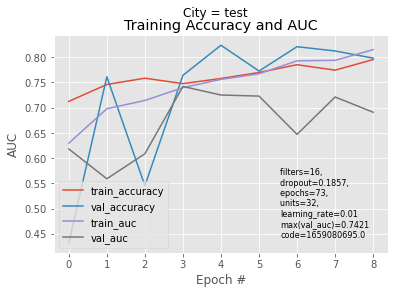

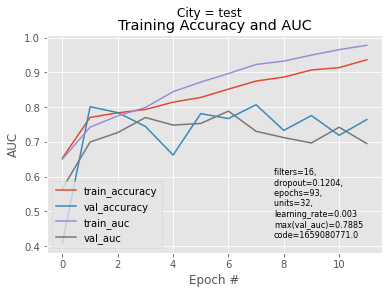

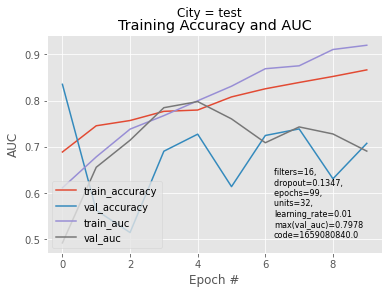

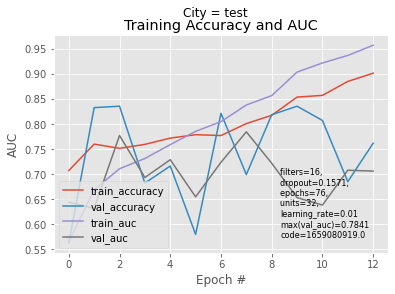

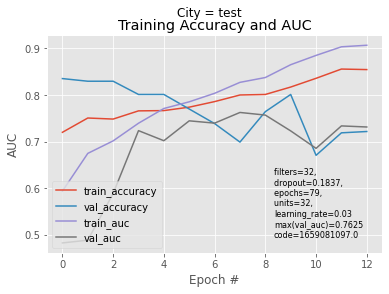

In [121]:
for i in range(0,5):
    m = run_model((train_images_t0, train_images_tt), train_labels, (valid_images_t0, valid_images_tt), valid_labels, run_id=i)
    model = m[0]
    history = m[1]
    parameters = m[2]
    print("Model optimization complete..\n\n")
    ts = str(np.round(time.time()))
    with open(f'../models/{CITY}_SNN_RUN{i}_{ts}_hist', 'wb') as file_pi:
        pickle.dump(history.history, file_pi)
    
    model.save(f'../models/{CITY}_SNN_RUN{i}_{ts}', save_format="h5")
    plot_training(history, parameters, ts, f'../figures/{CITY}_SNN_RUN{i}_{ts}.png')
    
    with open('../models/run_parameters.txt', "a") as file:
        file.write(f'{CITY}_SNN_RUN{i}_{ts}: \n \t{parameters}\n')
      


In [20]:
# for i in range(0,5):
#     m = run_model_dist((train_images_t0, train_images_tt), train_labels, (valid_images_t0, valid_images_tt), valid_labels, run_id=i)
#     model = m[0]
#     history = m[1]
#     parameters = m[2]
#     print("Model optimization complete..\n\n")
#     ts = str(np.round(time.time()))
#     with open(f'../models/{CITY}_SNN_RUN{i}_{ts}_hist', 'wb') as file_pi:
#         pickle.dump(history.history, file_pi)
    
#     model.save(f'../models/{CITY}_SNN_RUN{i}_{ts}', save_format="h5")
#     plot_training(history, parameters, ts, f'../figures/{CITY}_SNN_RUN{i}_{ts}.png')
    
#     with open('../models/run_parameters.txt', "a") as file:
#         file.write(f'{CITY}_SNN_RUN{i}_{ts}: \n \t{parameters}\n')

2022-07-29 13:39:24.994516: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 1 
Test Set AUC Score for the ROC Curve: 0.7834198385236448 
Average precision:  0.42001001295561446


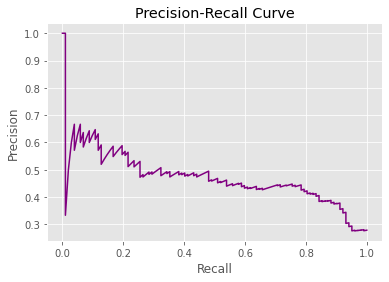

2022-07-29 13:39:28.185429: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 2 
Test Set AUC Score for the ROC Curve: 0.6686274509803921 
Average precision:  0.30200321444761513


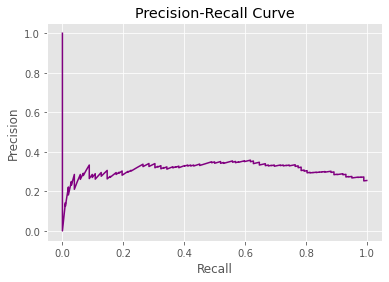

2022-07-29 13:39:32.029982: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 3 
Test Set AUC Score for the ROC Curve: 0.790513264129181 
Average precision:  0.43020564697681907


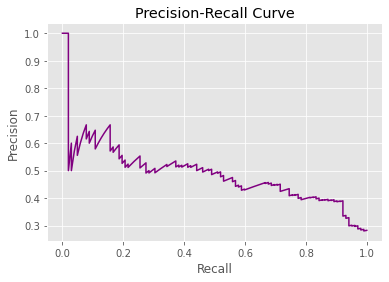

2022-07-29 13:39:35.611245: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 4 
Test Set AUC Score for the ROC Curve: 0.7843137254901961 
Average precision:  0.42580252682260844


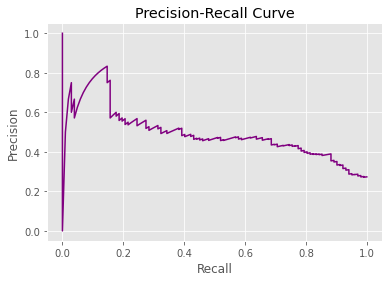

2022-07-29 13:39:38.720972: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 5 
Test Set AUC Score for the ROC Curve: 0.7771049596309112 
Average precision:  0.41905328234947276


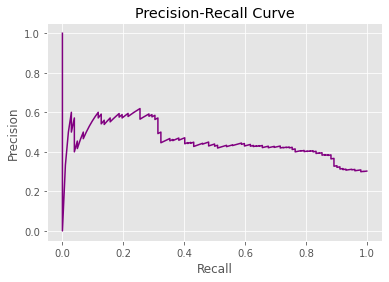

In [125]:
class SiameseTestGenerator(Sequence):
    def __init__(self, images, batch_size=BATCH_SIZE):
        self.images_t0 = images[0]
        self.images_tt = images[1]
        self.batch_size = batch_size
        self.tuple_pairs = make_tuple_pair(self.images_t0.shape[0], self.batch_size)
        np.random.shuffle(self.tuple_pairs)

    def __len__(self):
        return len(self.images_t0)//self.batch_size
    
    def __getitem__(self, index):
        
#         index_range = self.tuple_pairs[index]
#         indices = np.arange(0,32)
#         np.random.shuffle(indices)

#         X_t0 = self.images_t0[index_range[0]:index_range[1]][indices]
#         X_t1 = self.images_tt[index_range[0]:index_range[1]][indices]
        
#         alpha = 1
        
#         return {'images_t0':X_t0 *alpha, 'images_tt':X_t1 *alpha}
        
        if(index == self.__len__()-1):
            X_t0 = self.images_t0[index*self.batch_size:len(self.images_t0)]
            X_tt = self.images_tt[index*self.batch_size:len(self.images_tt)]
        else:
            X_t0 = self.images_t0[index*self.batch_size:(index+1)*self.batch_size]          
            X_tt = self.images_tt[index*self.batch_size:(index+1)*self.batch_size]          
    
        
        return {'images_t0':X_t0, 'images_tt':X_tt}



for i in range(0, 5):
    model_path = f'../models/{CITY}/snn/run_{i}'
    best_model = load_model(model_path, custom_objects={'auc':metrics.AUC(num_thresholds=200, curve='ROC', name='auc')})
    test_generator = SiameseTestGenerator((test_images_t0, test_images_tt))
    yhat_proba, y = np.squeeze(best_model.predict(test_generator)), np.squeeze(test_labels[:])
    roc_auc_test = roc_auc_score(y, yhat_proba)
    #calculate precision and recall
    precision, recall, thresholds = precision_recall_curve(y, yhat_proba)


    #create precision recall curve
    fig, ax = plt.subplots()
    ax.plot(recall, precision, color='purple')

    #add axis labels to plot
    ax.set_title('Precision-Recall Curve')
    ax.set_ylabel('Precision')
    ax.set_xlabel('Recall')

    print(f'Run {i+1} \nTest Set AUC Score for the ROC Curve: {roc_auc_test} \nAverage precision:  {np.mean(precision)}' )
    #display plot
    plt.show()

```
filters=32, dropout=0.13163265306122449, epochs=77, units=32, learning_rate=0.01
filters=32, dropout=0.18571428571428572, epochs=88, units=48, learning_rate=0.003

Upto 88
filters=32, 
dropout=0.1939, 
epochs=77, 
units=32, 
learning_rate=0.012


```